In [59]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

### Using Airpassenger data of past to predict future air passenger traffic

In [60]:
data = pd.read_csv('AirPassengers.csv',parse_dates=[0],index_col =[0])

In [61]:
data

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   #Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


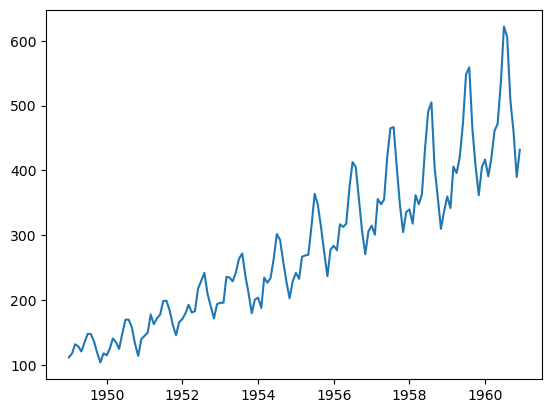

In [63]:
import matplotlib.pyplot as plt
plt.plot(data)
plt.show()

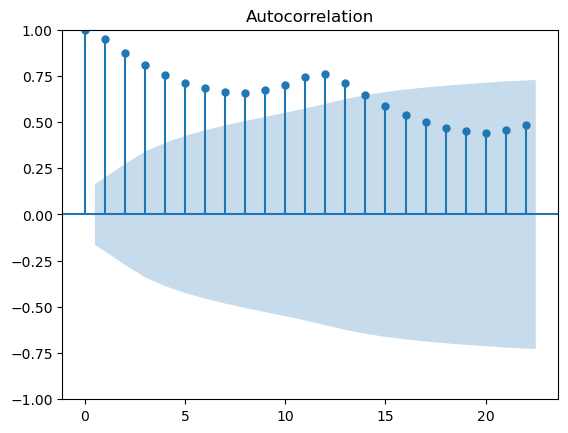

In [64]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data);

In [65]:
# from statsmodels.graphics.tsaplots import plot_pacf
# plot_pacf(data);

In [66]:
#data.diff(periods=1)
data1 = data.diff(periods=1).iloc[1:]

In [67]:
data1

,#Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


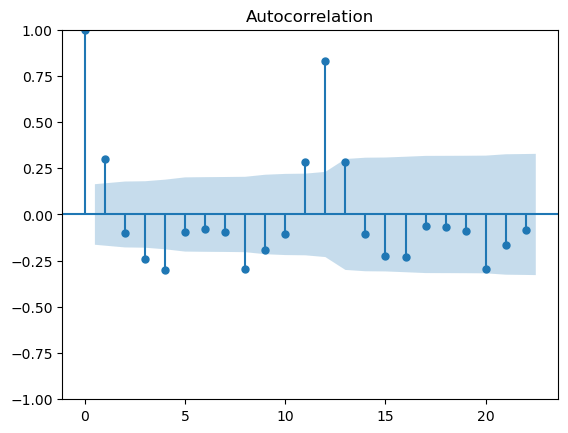

In [68]:
plot_acf(data1);

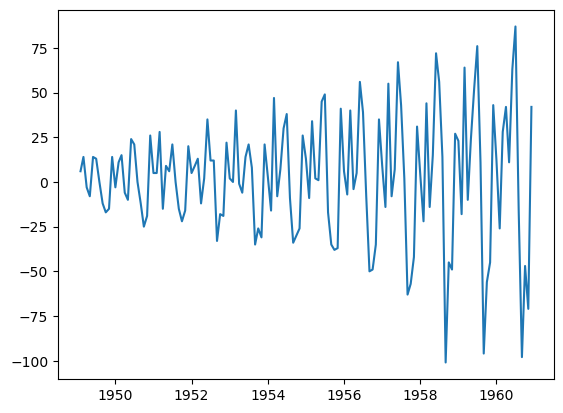

In [69]:
plt.plot(data1)
plt.show()

In [70]:
train = data1[:100]
test =data1[100:]

In [71]:
#Basic autoregression
from statsmodels.tsa.ar_model import ar_select_order   
mod = ar_select_order(data,maxlag=15,glob=True)   #Gives you the best lags as an array
mod.ar_lags

[1, 2, 12, 13, 14]

In [72]:
from statsmodels.tsa.ar_model import AutoReg
ar_model = AutoReg(data[:100],lags=[1, 2, 12, 13, 14])  #Creating a model
my_model = ar_model.fit()    #Fitting the model

In [73]:
pred = my_model.predict(start=100,end=142)    #Making predictions

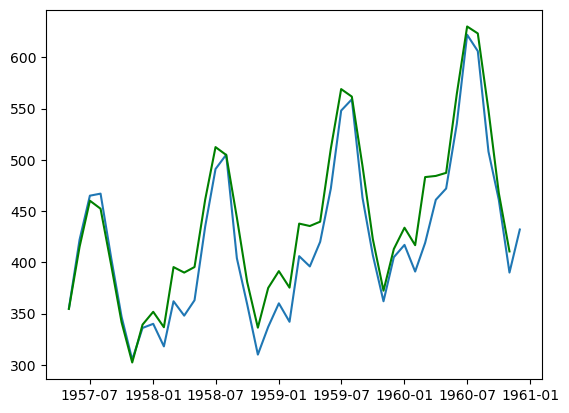

In [74]:
plt.plot(data[100:])   #Graphing actuals
plt.plot(pred,color='green')   #Graphing prediction   

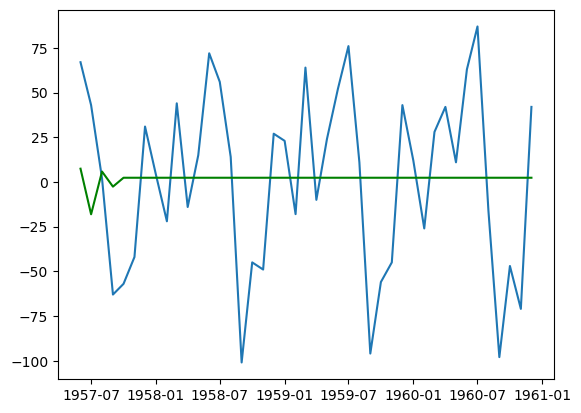

In [75]:
#For MA, we don't have direct implmentations
#You can use arima (p,d,q) - Make p and d as zero, so that effectively i'm implementing a MA model
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1[:100],order=(0,0,4))
my_model = model.fit()
pred = my_model.predict(start=100,end=142)
plt.plot(data1[100:])   #Graphing actuals
plt.plot(pred,color='green')   #Graphing prediction  

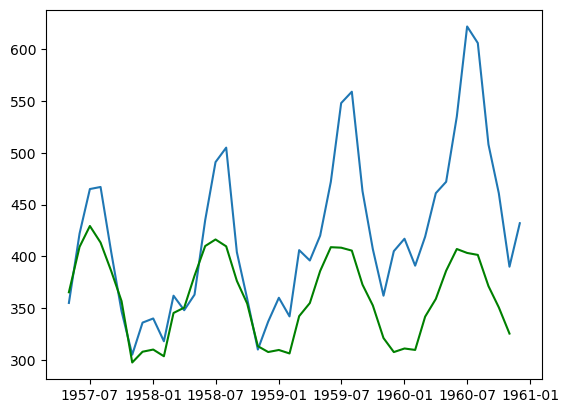

In [76]:
#Full ARIMA implemented
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data[:100],order=(8,1,4))
my_model = model.fit()
pred = my_model.predict(start=100,end=142)
plt.plot(data[100:])   #Graphing actuals
plt.plot(pred,color='green')   #Graphing prediction  

In [77]:
import itertools
p = range(0,4)
d = range(0,4)
q = range(0,4)
pdq = list(itertools.product(p,d,q))
pdq

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 0, 3),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (0, 2, 3),
 (0, 3, 0),
 (0, 3, 1),
 (0, 3, 2),
 (0, 3, 3),
 (1, 0, 0),
 (1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 0),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (1, 2, 0),
 (1, 2, 1),
 (1, 2, 2),
 (1, 2, 3),
 (1, 3, 0),
 (1, 3, 1),
 (1, 3, 2),
 (1, 3, 3),
 (2, 0, 0),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 0),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (2, 2, 0),
 (2, 2, 1),
 (2, 2, 2),
 (2, 2, 3),
 (2, 3, 0),
 (2, 3, 1),
 (2, 3, 2),
 (2, 3, 3),
 (3, 0, 0),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 0),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3),
 (3, 2, 0),
 (3, 2, 1),
 (3, 2, 2),
 (3, 2, 3),
 (3, 3, 0),
 (3, 3, 1),
 (3, 3, 2),
 (3, 3, 3)]

In [78]:
import warnings
warnings.filterwarnings("ignore")

list_params = []
list_aic = []

for params in pdq:
    try:
        model = ARIMA(data[:100], order=params)
        model_fit = model.fit()

        list_params.append(params)
        list_aic.append(model_fit.aic)

    except:
        continue

best_idx = list_aic.index(min(list_aic))

print(f"Lowest AIC : {list_aic[best_idx]:.2f}")
print(f"Best Order : ARIMA{list_params[best_idx]}")

Lowest AIC : 874.85
Best Order : ARIMA(3, 1, 3)


In [79]:
# Create the final ARIMA model using the best (p, d, q) values
final_model = ARIMA(data[:100], order=best_order)

# Train (fit) the final ARIMA model
final_model_fit = final_model.fit()

# Print the AIC value of the final trained model
print(f"Final model AIC: {final_model_fit.aic:.2f}")

Final model AIC: 874.85


In [80]:
# pred = model_fit.predict(
#     start=100,
#     end=len(data)-1
# )
model = ARIMA(data,
              order=(8,1,4))

model_fit = model.fit()

forecast = model_fit.forecast(steps=36)

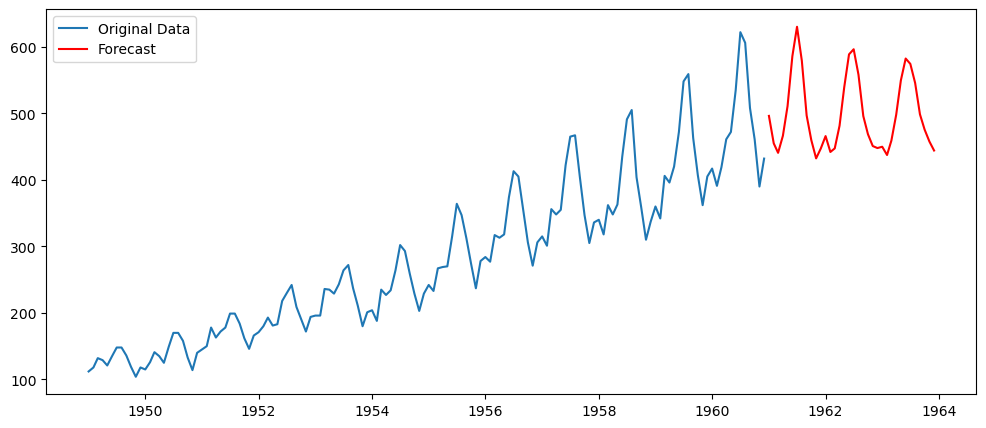

In [81]:
plt.figure(figsize=(12,5))

plt.plot(data, label='Original Data')

plt.plot(forecast,
         label='Forecast',
         color='red')

plt.legend()

plt.show()

In [82]:
print(forecast.index)

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01',
               '1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01', '1962-11-01', '1962-12-01',
               '1963-01-01', '1963-02-01', '1963-03-01', '1963-04-01',
               '1963-05-01', '1963-06-01', '1963-07-01', '1963-08-01',
               '1963-09-01', '1963-10-01', '1963-11-01', '1963-12-01'],
              dtype='datetime64[ns]', freq='MS')


In [83]:
pwd

'C:\\Users\\Lenovo\\Downloads\\Time Series-20260715T110250Z-1-001\\Time Series'